In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from renderer import RelativeSpec, FigureSpec, BoxPatch, ImagePatch, TextPatch, CubePatch, ArrowConnector, render_objects
from dinosaw.helpers import add_custom_font

flash attention installed


In [2]:
add_custom_font('resources/fonts', 'Grotesk')

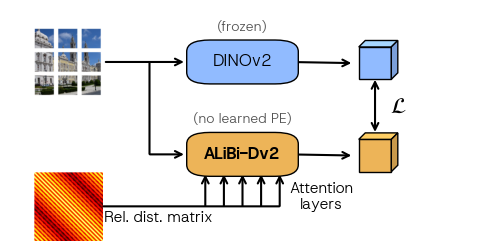

In [51]:
W, H = 6, 3
fig = plt.figure(figsize=(W, H))
ax = plt.gca()

R_BOX_WIDTH = 0.2
R_BOX_HEIGHT = 0.15
R_BOX_SEP = 0.4


DINO_COLOR = '#91bbff'
ALIBI_COLOR = '#EDB458'
alibi_box = BoxPatch(FigureSpec(0.4, 0.3, R_BOX_WIDTH, R_BOX_HEIGHT,), fancy=True, facecolor=ALIBI_COLOR)
alibi_text = TextPatch(RelativeSpec(alibi_box, (0.05, 0.025), 0.1, 0.1), "ALiBi-Dv2", fontsize=12, ha="center", va="center", bold=True)
remove_pe_text = TextPatch(RelativeSpec(alibi_text, (0, 0.15), 0.1, 0.1), "(no learned PE)", fontsize=10, ha="center", va="center", color="#555555")

dino_box = BoxPatch(RelativeSpec(alibi_box, (0, R_BOX_SEP), R_BOX_WIDTH, R_BOX_HEIGHT,), fancy=True, facecolor=DINO_COLOR)
dino_text = TextPatch(RelativeSpec(dino_box, (0.05, 0.025), 0.1, 0.1), "DINOv2", fontsize=12, ha="center", va="center")
frozen_text = TextPatch(RelativeSpec(dino_text, (0, 0.15), 0.1, 0.1), "(frozen)", fontsize=10, ha="center", va="center", color="#555555")

IMG_L  = 0.15
img = np.array(Image.open("data/summary/gv/patches.png"))

IMG_REL_LOC = (-0.35, -IMG_L /2)
patch_img = ImagePatch(RelativeSpec(dino_box, IMG_REL_LOC, IMG_L, (W / H) * IMG_L), img)


MAT_L  = 0.15
DIST_MAT_REL_LOC = (-0.35, -2.0 * MAT_L)
dist_mat = np.array(Image.open("data/summary/gv/alibi_224.png"))
dist_mat_img = ImagePatch(RelativeSpec(alibi_box, DIST_MAT_REL_LOC, MAT_L, (W / H) * MAT_L), dist_mat)

CUBE_L = 0.07
dino_cube = CubePatch(RelativeSpec(dino_box, (0.35, 0), CUBE_L, (W / H) * CUBE_L), depth_ratio=0.2, color=DINO_COLOR)
alibi_cube = CubePatch(RelativeSpec(dino_cube, (0.0, -R_BOX_SEP), CUBE_L, (W / H) * CUBE_L), depth_ratio=0.2, color=ALIBI_COLOR)



l1 = ArrowConnector(patch_img, dino_box, ('right', 0.5), ('left', 0.5 ), shrinkB=0.02)
l2 = ArrowConnector(l1, RelativeSpec(alibi_box, (-0.1, R_BOX_HEIGHT / 2), 0, 0), ('bottom', 0.5), arrowstyle='-', shrinkA=-0.01, shrinkB=-0.01)
l3 = ArrowConnector(l2, alibi_box, ('right', 0.0), ('left', 0.5), arrowstyle='->', shrinkA=-0.005, shrinkB=0.02)
l4 = ArrowConnector(dino_box, dino_cube, ('right', 0.5), ('left', 0.5), shrinkB=0.01)
l5 = ArrowConnector(alibi_box, alibi_cube, ('right', 0.5), ('left', 0.5), shrinkB=0.01)
l6 = ArrowConnector(dino_cube, alibi_cube, ('bottom', 0.5), ('top', 0.5), shrinkA=-0.01, shrinkB=0.02, arrowstyle='<->')
l7 = ArrowConnector(dist_mat_img, RelativeSpec(alibi_box, (0.185, -1 * MAT_L), 0.0, 0.0), ('right', 0.5), arrowstyle='-', shrinkA=-0.005)

loss_text = TextPatch(RelativeSpec(l6, (0.05, 0.14), 0.0, 0.0), r"$\mathcal{L}$", fontsize=16, ha="center", va="center", bold=True)
rel_dist_text = TextPatch(RelativeSpec(l7, (0.12, -0.05), 0.0, 0.0), "Rel. dist. matrix", fontsize=11, ha="center", va="center")



# --- New: Internal and external connectors ---
# Set N for number of internal/external lines
N = 5
internal_lines = []
external_lines = []
for i in range(N):
    frac = (i + 0.5) / N  # center them in the box
    # Internal: top to bottom, dashed
    # internal = ArrowConnector(alibi_box, alibi_box, ('top', frac), ('bottom', frac), arrowstyle='-', linestyle='dashed', color='#c0c1c2')
    # internal_lines.append(internal)
    # External: from l7 (relative start) to the top edge of each internal line
    # Use RelativeSpec to position start near l7, and connect to ('top', frac) of alibi_box
    ext_start = RelativeSpec(l7, (0.45 + frac, 0.05), 0, 0)
    external = ArrowConnector(alibi_box, None, ('bottom', frac), None, dx=0, dy=-0.16,
                               arrowstyle='<-', linestyle='solid')
    external_lines.append(external)


attn_text = TextPatch(RelativeSpec(external, (0.09, 0.05), 0.0, 0.0), "Attention\nlayers", fontsize=11, ha="center", va="center")

# ---
lines = [l1, l2, l3, l4, l5, l6, l7]  + external_lines
boxes = [  alibi_box, dino_box] + internal_lines
cubes = [dino_cube, alibi_cube]
images = [patch_img, dist_mat_img]
text = [alibi_text, frozen_text, dino_text, remove_pe_text, loss_text, rel_dist_text, attn_text]

objs = lines + boxes + cubes + images + text

# render_objects(ax, [l1, l2, l3, l4, l5, l6, alibi_box, alibi_text, dino_box, dino_text, patch_img, dist_mat_img, dino_cube, alibi_cube, loss_text], grid_shape=(1, 2))
render_objects(ax, objs, grid_shape=(1, 2))
plt.show()

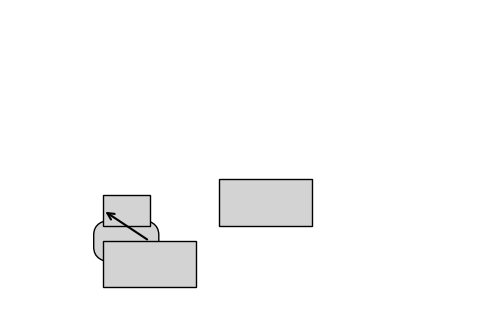

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))

a = BoxPatch(FigureSpec(0.2, 0.2, 0.1, 0.1,), fancy=True)
b = BoxPatch(FigureSpec(0.2, 0.3, 0.1, 0.1))
c = BoxPatch(FigureSpec(0.2, 0.1, 0.2, 0.15))
d = BoxPatch(RelativeSpec(c, (0.25, 0.2), 0.2, 0.15))

arr1 = ArrowConnector(a, b, ("right", 0.5), ("left", 0.5))
arr2 = ArrowConnector(arr1, c, ("bottom", 1.0), ("top", 0.5))

render_objects(ax, [a, b, c, arr1, arr2, d], grid_shape=(1, 2))

plt.show()